In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import MODELS, load_data, opinions

runs, banks, P, GCLASS = load_data()
REGIMES = ["objective", "subjective"]
COL = {"C": "#1f4e79", "P": "#5dade2", "I": "#8e44ad"}
CONV = ["sq", "abs"]  # conviction variants: mean m_i^2 vs mean |m_i|
T = 9

for r in runs:
    op = opinions(r)                                 # (9, 32) k=5-resample means
    r["n"] = op.mean(axis=1)                         # net opinion n(t)
    r["mag"] = {"sq": (op ** 2).mean(axis=1), "abs": np.abs(op).mean(axis=1)}
print(len(runs), "societies")

9600 societies


In [2]:
shares = {}
for model, label, short in MODELS:
    for regime in REGIMES:
        rows = [r for r in runs if r["model"] == model and r["mode"] == regime]
        for cv in CONV:
            mag_cut = np.quantile(np.concatenate([r["mag"][cv] for r in rows]), 1 / 3)
            abs_n = np.concatenate([np.abs(r["n"])[r["mag"][cv] >= mag_cut]
                                    for r in rows])
            n_cut = np.quantile(abs_n, 0.5)
            cnt = dict.fromkeys("CPI", 0)
            for r in rows:
                ph = np.where(r["mag"][cv] < mag_cut, "I",
                              np.where(np.abs(r["n"]) > n_cut, "C", "P"))
                r.setdefault("ph", {})[cv] = ph
                for c in ph:
                    cnt[c] += 1
            tot = sum(cnt.values())
            shares[short, regime, cv] = {c: 100 * cnt[c] / tot for c in "CPI"}

pd.DataFrame({(sh, rg): {f"{c} ({cv})": round(shares[sh, rg, cv][c], 1)
                         for cv in CONV for c in "CPI"}
              for _, _, sh in MODELS for rg in REGIMES}).T

C (sq)  P (sq)  I (sq)  C (abs)  P (abs)  I (abs)
gpt objective     34.2    35.1    30.7     33.9     34.2     31.9
    subjective    35.3    35.8    28.9     35.3     35.8     28.9
gma objective     32.6    35.0    32.4     32.6     34.5     32.9
    subjective    33.1    34.5    32.3     33.1     34.5     32.5
qwn objective     32.8    34.0    33.2     32.8     34.4     32.8
    subjective    32.9    33.9    33.2     35.3     36.2     28.5
lma objective     32.6    34.2    33.2     33.4     34.9     31.7
    subjective    34.4    35.7    30.0     32.5     35.1     32.4

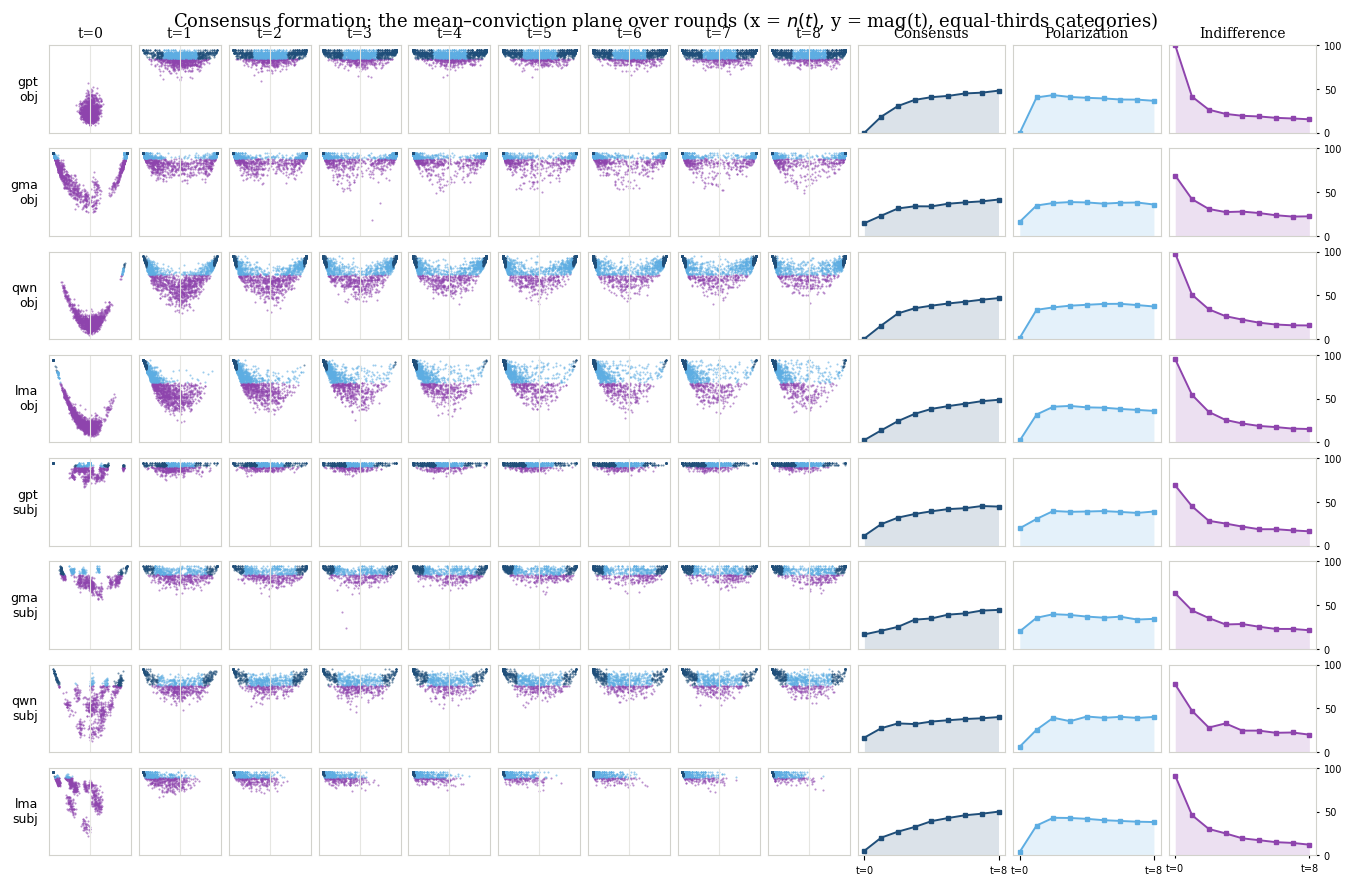

In [3]:
# the mean-conviction plane over rounds (x = net opinion n(t), y = mag(t)):
# 9 scatter panels + 3 per-category share columns per (regime, model) row
cv = "sq"
panels = [(m, l, s, rg) for rg in REGIMES for m, l, s in MODELS]
all_n = np.concatenate([r["n"] for r in runs])
all_g = np.concatenate([r["mag"][cv] for r in runs])
pad6 = lambda lo, hi: (lo - (hi - lo) * 0.06, hi + (hi - lo) * 0.06)
rx, ry = pad6(all_n.min(), all_n.max()), pad6(all_g.min(), all_g.max())

fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(len(panels), 12, wspace=0.08, hspace=0.18,
                      width_ratios=[1] * 9 + [1.8] * 3,
                      left=0.06, right=0.965, top=0.94, bottom=0.04)
for row, (model, label, short, regime) in enumerate(panels):
    rows = [r for r in runs if r["model"] == model and r["mode"] == regime]
    net = np.array([r["n"] for r in rows])
    G = np.array([r["mag"][cv] for r in rows])
    PH = np.array([r["ph"][cv] for r in rows])
    ax_first = None
    for t in range(T):
        ax = fig.add_subplot(gs[row, t])
        ax_first = ax_first or ax
        ax.axvline(0, color="#e6e6e2", lw=0.8)
        for c in "IPC":                              # draw I under P under C
            sel = PH[:, t] == c
            ax.scatter(net[sel, t], G[sel, t], s=2.2, c=COL[c], alpha=0.6, lw=0)
        ax.set_xlim(rx), ax.set_ylim(ry)
        ax.set_xticks([]), ax.set_yticks([])
        for s in ax.spines.values():
            s.set_color("#d2d2cc")
        if row == 0:
            ax.set_title(f"t={t}", fontsize=10, family="serif")
    pos = ax_first.get_position()
    fig.text(0.052, pos.y0 + pos.height / 2,
             f"{short}\n{'obj' if regime == 'objective' else 'subj'}",
             ha="right", va="center", fontsize=9)
    for j, (c, name) in enumerate(zip("CPI", ["Consensus", "Polarization",
                                              "Indifference"])):
        ax = fig.add_subplot(gs[row, 9 + j])
        share = 100 * (PH == c).mean(axis=0)
        ax.fill_between(range(T), share, color=COL[c], alpha=0.16, lw=0)
        ax.plot(range(T), share, color=COL[c], lw=1.4, marker="s", ms=2.6)
        ax.set_xlim(-0.4, T - 0.6), ax.set_ylim(0, 100)
        ax.set_xticks([]), ax.set_yticks([])
        if j == 2:
            ax.set_yticks([0, 50, 100])
            ax.yaxis.tick_right()
            ax.tick_params(labelsize=7, length=2)
        for s in ax.spines.values():
            s.set_color("#d2d2cc")
        if row == 0:
            ax.set_title(name, fontsize=10, family="serif")
        if row == len(panels) - 1:
            ax.set_xticks([0, T - 1], ["t=0", f"t={T - 1}"], fontsize=7)
fig.suptitle(r"Consensus formation: the mean–conviction plane over rounds "
             r"(x = $n(t)$, y = mag(t), equal-thirds categories)",
             fontsize=13, family="serif")
plt.show()

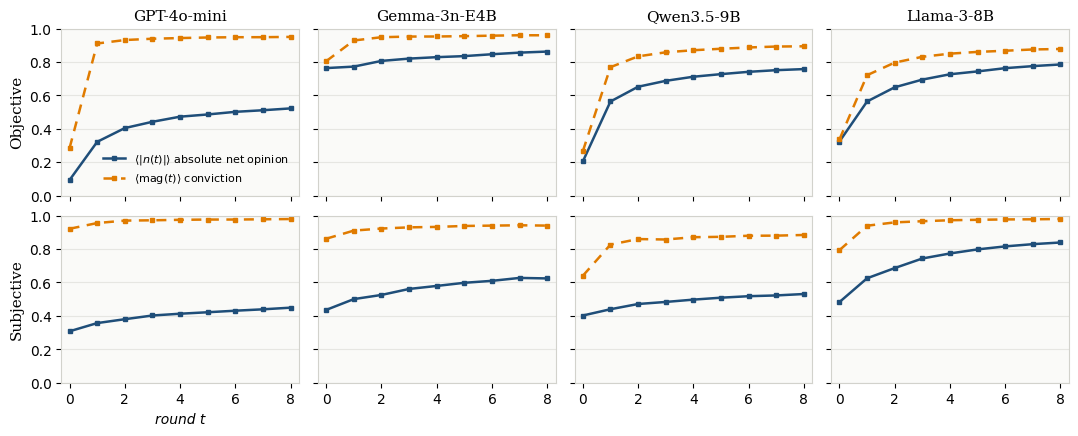

In [4]:
# marginal view: society-averaged |n(t)| (solid blue) vs conviction mag(t)
# (dashed orange) per (regime, model) panel
fig, axes = plt.subplots(2, 4, figsize=(13, 4.6), sharex=True, sharey=True,
                         gridspec_kw=dict(wspace=0.08, hspace=0.12))
for i, regime in enumerate(REGIMES):
    for j, (model, label, short) in enumerate(MODELS):
        ax = axes[i, j]
        rows = [r for r in runs if r["model"] == model and r["mode"] == regime]
        absn = np.mean([np.abs(r["n"]) for r in rows], axis=0)
        conv = np.mean([r["mag"][cv] for r in rows], axis=0)
        ax.set_facecolor("#fafaf8")
        ax.grid(axis="y", color="#e6e6e2", lw=0.8)
        ax.plot(range(T), absn, color="#1f4e79", lw=1.8, marker="s", ms=3,
                label=r"$\langle|n(t)|\rangle$ absolute net opinion")
        ax.plot(range(T), conv, color="#e07b00", lw=1.8, ls=(0, (4, 3)),
                marker="s", ms=3, label=r"$\langle$mag$(t)\rangle$ conviction")
        ax.set_ylim(0, 1), ax.set_xlim(-0.3, T - 0.7)
        ax.set_xticks(range(0, T, 2))
        if i == 0:
            ax.set_title(label, fontsize=11, family="serif")
        if j == 0:
            ax.set_ylabel(regime.capitalize(), fontsize=11, family="serif")
        for s in ax.spines.values():
            s.set_color("#d2d2cc")
axes[1, 0].set_xlabel("round t", fontsize=10, style="italic")
axes[0, 0].legend(loc="lower right", fontsize=8, frameon=False)
plt.show()